# **Penting**
- Jangan menambahkan import libary atau function apa pun, selain yang sudah tersedia pada cell code.
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Ingat, tugas Anda hanyalah melengkapi code yang rumpang pada bagian yang sudah ditandai "________" saja.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan juga output yang dihasilkan sesuai dengan output yang diharapkan (expected output). Sehingga Anda dapat mereview sendiri terlebih dahulu output dari cell code yang dijalankan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [29]:
# Load data

### MULAI CODE ###

url='https://docs.google.com/spreadsheets/d/e/2PACX-1vTbg5WVW6W3c8SPNUGc3A3AL-AG32TPEQGpdzARfNICMsLFI0LQj0jporhsLCeVhkN5AoRsTkn08AYl/pub?output=csv'
df = pd.read_csv(url)

### SELESAI CODE ###

In [30]:
# Tampilkan 5 baris pertama dengan function head.

### MULAI CODE ###

df.head()

### SELESAI CODE ###

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 8:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 8:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 8:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 8:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 8:06:39


In [31]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.

### MULAI CODE ###

df.info()

### SELESAI CODE ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   PreviousTransactionDate  2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [32]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe

### MULAI CODE ###

df.describe()

### SELESAI CODE ###

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [33]:
# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=['number']).columns

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

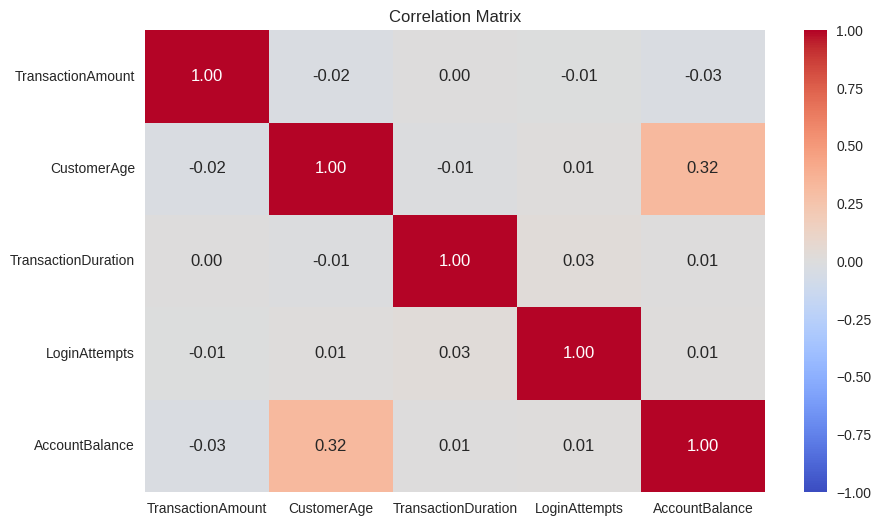

In [34]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)

### MULAI CODE ###

# Hitung matriks korelasi
correlation = df[numerical_cols].corr()

# Buat visualisasi heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            vmin=-1,
            vmax=1)
plt.title('Correlation Matrix')
plt.show()

### SELESAI CODE ###

Analisis Correlation Matrix

Berdasarkan visualisasi **Correlation Matrix** pada fitur numerik utama, ditemukan beberapa poin penting untuk tahap modeling clustering:

* **Korelasi Linear Sangat Lemah:** Mayoritas fitur seperti `TransactionAmount`, `TransactionDuration`, dan `LoginAttempts` memiliki nilai korelasi yang mendekati nol (-0.03 hingga 0.03). Hal ini menandakan bahwa tidak ada hubungan linear antar variabel tersebut, sehingga tidak ada risiko *multicollinearity* (redundansi data) yang dapat mengganggu algoritma berbasis jarak.
* **Hubungan Usia dan Saldo:** Terdapat korelasi positif moderat sebesar **0.32** antara `CustomerAge` dan `AccountBalance`. Secara finansial ini logis, karena nasabah yang berusia lebih tua cenderung memiliki akumulasi saldo tabungan yang lebih tinggi.
* **Implikasi Deteksi Fraud/Anomali:** Karena indikator anomali seperti jumlah percobaan login (`LoginAttempts`) dan durasi transaksi (`TransactionDuration`) tidak berkorelasi linear dengan nilai transaksi (`TransactionAmount`), pola penipuan tidak dapat dideteksi dengan aturan linear sederhana. Algoritma clustering (seperti **K-Means** atau **DBSCAN**) sangat tepat digunakan di sini untuk menangkap struktur kelompok non-linear atau pencilan (*outliers*) yang terisolasi dari perilaku transaksi normal.


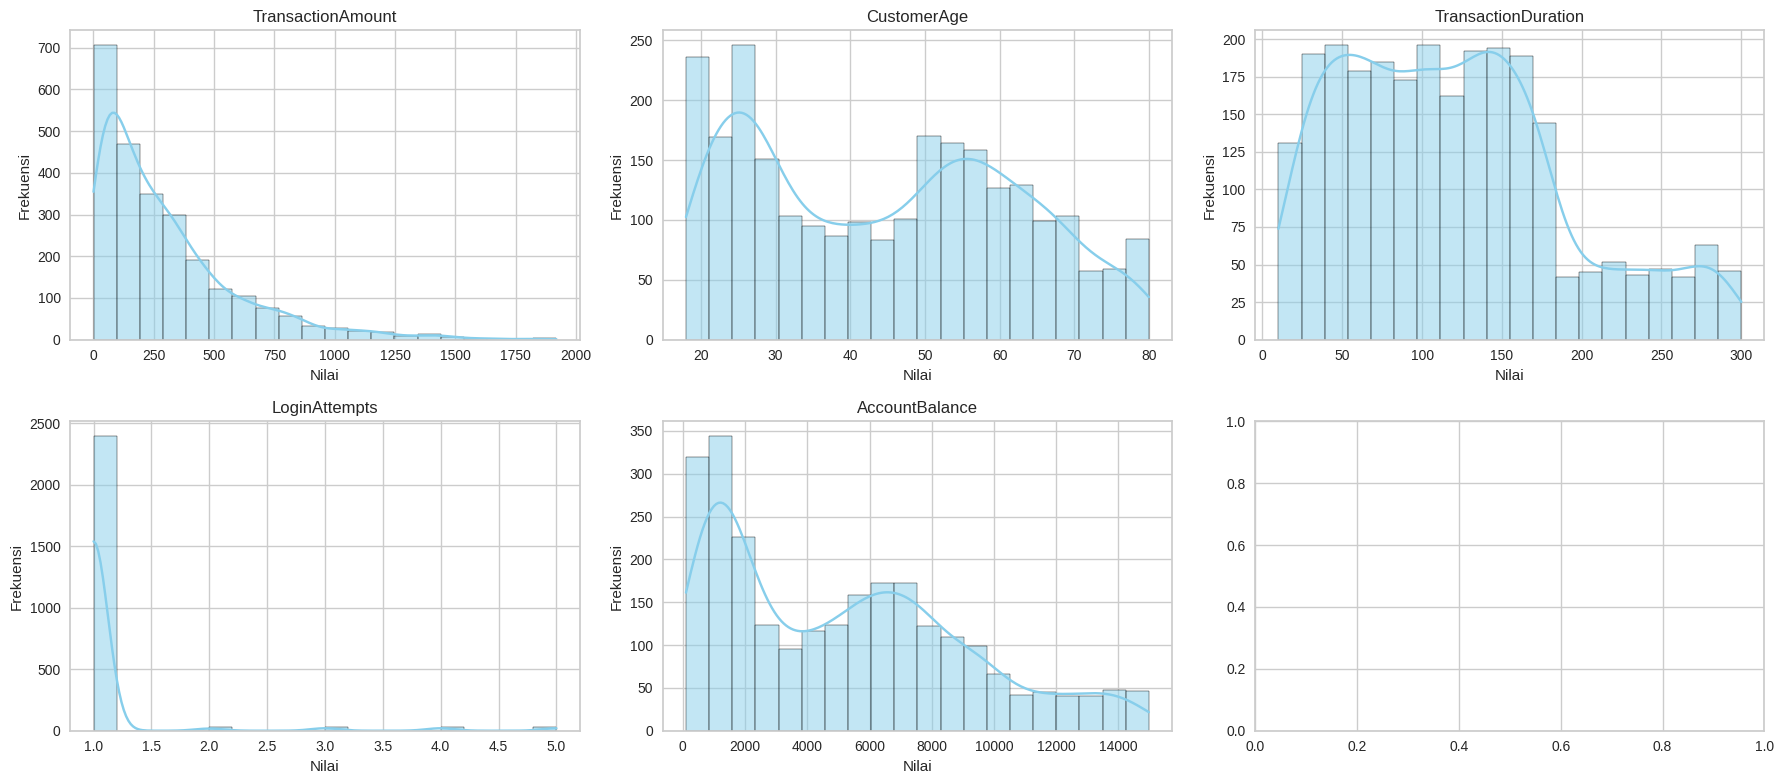

In [35]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, column in enumerate(numerical_cols):

    ### MULAI CODE ###

    # Tampilkan histogram dan pastikan plot ditempatkan di subplot (axes) yang benar
    sns.histplot(df[column], bins=20, kde=True, color='skyblue', ax=axes[i])

    # Atur judul dan label
    axes[i].set_title(column)
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")

    ### SELESAI CODE ###

plt.tight_layout()
plt.show()

Analisis Distribusi Data (Histogram & KDE)

Berdasarkan visualisasi grafik distribusi (Histogram dan Kernel Density Estimate) untuk fitur-fitur numerik utama, berikut adalah karakteristik data yang krusial untuk proyek clustering deteksi anomali:

* **TransactionAmount & AccountBalance (Right-Skewed):** Kedua fitur keuangan ini menunjukkan pola *right-skewed* (condong ke kanan) yang sangat kuat. Mayoritas transaksi bernilai kecil (di bawah 500) dan mayoritas nasabah memiliki saldo rendah (di bawah 2000). Namun, terdapat *long-tail* yang memanjang ke kanan hingga nilai transaksi >1500 dan saldo >14000. Data pencilan (*outliers*) di area ekor kanan ini berpotensi besar menjadi indikator transaksi anomali atau *high-value fraud*.
* **CustomerAge & AccountBalance (Bimodal Distribution):** Menariknya, fitur `CustomerAge` dan `AccountBalance` sama-sama membentuk distribusi *bimodal* (memiliki dua puncak). Puncak pertama berada di kelompok usia muda (20-30 tahun) dengan saldo rendah, dan puncak kedua berada di kelompok usia matang/senior (50-60 tahun) dengan saldo menengah ke atas. Pola kembar ini mengonfirmasi hasil korelasi sebelumnya (0.32) dan mengindikasikan bahwa algoritma clustering akan dengan mudah memisahkan dua segmen demografi utama ini.
* **TransactionDuration (Multimodal/Uniform Block):** Durasi transaksi menunjukkan pola yang cukup merata (*uniform*) di rentang 25 hingga 160 detik sebelum mengalami penurunan drastis pada durasi >170 detik. Transaksi yang memakan waktu sangat lama (di atas 200 hingga 300 detik) berjumlah sedikit dan patut dicurigai sebagai *bot behavior* atau kendala sistem saat transaksi tidak wajar terjadi.
* **LoginAttempts (Extreme Outliers):** Fitur ini didominasi secara mutlak oleh angka 1 (login sukses dalam sekali percobaan). Namun, grafik mendeteksi adanya titik-titik pencilan kecil yang melakukan percobaan login hingga 5 kali. Dalam konteks *fraud detection*, klaster atau data yang masuk dalam kategori `LoginAttempts` tinggi ini wajib diwaspadai sebagai indikasi serangan *brute force* atau pembajakan akun (*account takeover*).


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

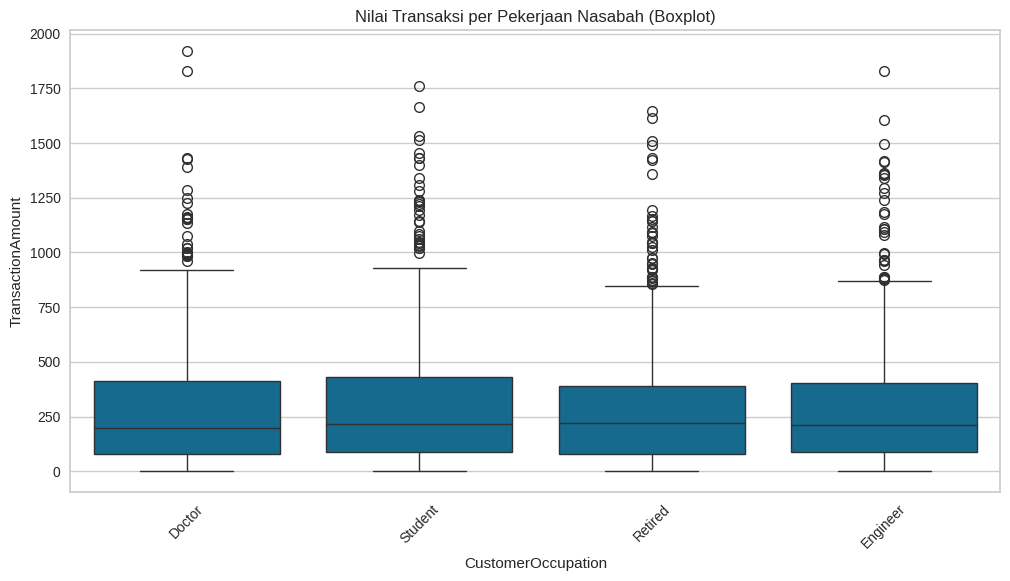

In [36]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

### MULAI CODE ###

plt.figure(figsize=(12, 6))

# Buat visualisasi boxplot untuk melihat sebaran 'TransactionAmount' (y) berdasarkan 'CustomerOccupation' (x)
sns.boxplot(x='CustomerOccupation', y='TransactionAmount', data=df)

plt.title("Nilai Transaksi per Pekerjaan Nasabah (Boxplot)")

# Putar label sumbu-x agar tidak tumpang tindih
plt.xticks(rotation=45)

plt.show()

### SELESAI CODE ###

# -----------------------------------------------------------------
# (TANTANGAN OPSIONAL)
# -----------------------------------------------------------------
# Sekarang, bagaimana jika kita juga ingin melihat kepadatan distribusi data di setiap kategori?
# Coba buat visualisasi lain di bawah ini, misalnya 'violinplot' (sns.violinplot) dengan parameter yang sama.

Analisis Nilai Transaksi per Pekerjaan Nasabah (Boxplot Outliers)

Berdasarkan visualisasi **Boxplot** antara pekerjaan nasabah (`CustomerOccupation`) dan nilai transaksi (`TransactionAmount`), ditemukan karakteristik penting mengenai perilaku belanja normal vs pencilan (*outliers*) di setiap kelompok:

* **Pola Transaksi Normal Seragam:** Secara umum, kotak interkuartil (IQR) untuk semua jenis pekerjaan (`Doctor`, `Student`, `Retired`, `Engineer`) berada di rentang nilai yang sangat mirip, yaitu mayoritas transaksi normal berkisar di bawah 500 dengan nilai median di sekitar 200. Artinya, profesi nasabah secara umum tidak mengubah perilaku pengeluaran harian/reguler mereka.
* **Deteksi Pencilan Masif (Potensi Fraud):** Batas atas (*whisker*) untuk transaksi normal di setiap pekerjaan berhenti di kisaran nilai 800 - 900. Di atas nilai tersebut, ditemukan banyak sekali titik pencilan (*outliers*) yang memanjang hingga nilai transaksi mendekati 2000.
* **Anomali Berdasarkan Profesi:**
    * **Doctor & Engineer:** Memiliki sebaran pencilan yang cukup padat di rentang 1000 - 1500, dengan beberapa transaksi ekstrem menyentuh angka ~1900 untuk Doctor. Pengeluaran besar pada profesi ini bisa jadi merupakan hal yang valid (daya beli tinggi), namun tetap perlu divalidasi oleh klaster.
    * **Student (Mahasiswa):** Ditemukan banyak pencilan bernilai tinggi (>1000) bahkan ada yang menembus angka ~1750. Dalam deteksi fraud, transaksi bernilai sangat besar pada akun mahasiswa (*Student*) sering kali menjadi *red flag* utama karena tidak sesuai dengan profil pendapatan finansial umum mereka. Ini berpotensi kuat menjadi klaster *fraud/account takeover*.
    * **Retired (Pensiunan):** Menunjukkan pencilan yang konsisten tinggi hingga kisaran 1600. Pola ini juga perlu diwaspadai sebagai potensi korban penipuan/scam yang menyasar kelompok lansia.

**Implikasi untuk Clustering:** visualisasi ini mempertegas bahwa fitur kategorikal `CustomerOccupation` dikombinasikan dengan pencilan pada `TransactionAmount` akan menjadi pembeda yang sangat kuat dalam membentuk klaster anomali. Klastering harus mampu memisahkan kelompok "Mahasiswa dengan Transaksi Ekstrem" sebagai salah satu kelompok berisiko tinggi.


# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan drop pada data null/nan dan data yang duplicate
3. Melakukan drop pada seluruh kolom id, address, dan date.
4. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [37]:
# Mengecek dataset menggunakan isnull().sum()

### MULAI CODE ###

df.isnull().sum()

### SELESAI CODE ###

,0
TransactionID,29
AccountID,21
TransactionAmount,26
PreviousTransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [38]:
# Mengecek dataset menggunakan duplicated().sum()

### MULAI CODE ###

df.duplicated().sum()

### SELESAI CODE ###

np.int64(21)

In [39]:
# Menangani data yang hilang.

### MULAI CODE ###

# Panggil fungsi untuk menghapus baris yang hilang dan pastikan agar perubahan disimpan kembali ke 'df'
df.dropna(inplace=True)

# Cek kembali dataset menggunakan isnull().sum()
df.isnull().sum()

### SELESAI CODE ###

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [40]:
# Menghapus data duplikat.

### MULAI CODE ###

# Panggil fungsi untuk menghapus baris duplikat dan pastikan agar perubahan disimpan kembali ke 'df'
df.drop_duplicates(inplace=True)

# Cek kembali dataset menggunakan duplicated().sum()
df.duplicated().sum()

### SELESAI CODE ###

np.int64(0)

In [41]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address

### MULAI CODE ###

# Buat list comprehension untuk memfilter nama kolom.
#    - Iterasi melalui semua nama kolom (col).
#    - Cek apakah 'id', 'ip', atau 'date' ada di nama kolom.
#    - Gunakan .lower() untuk membuat perbandingan case-insensitive (mengabaikan besar/kecil).

cols_to_drop = [col for col in df.columns if
                'id' in col.lower() or
                'ip' in col.lower() or
                'date' in col.lower()]

# Gunakan fungsi .drop() untuk menghapus kolom-kolom yang ada di 'cols_to_drop'.
df = df.drop(columns=cols_to_drop)

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68


In [42]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
# Pastikan kamu menggunakan function head setelah melalukan encoding.

### MULAI CODE ###

# Pilih semua kolom yang bertipe 'object' (kategorikal)
categorical_cols = list(df.select_dtypes(include=['object']).columns)

encoders = {}

# Loop melalui setiap kolom kategorikal
for column in categorical_cols:
    # Buat (instantiate) objek LabelEncoder
    label_encoder = LabelEncoder()

    # Terapkan (fit) encoder ke data dan sekaligus ubah (transform) data tersebut
    df[column] = label_encoder.fit_transform(df[column])

    # Simpan encoder
    encoders[column] = label_encoder

# Tampilkan 5 baris pertama untuk memverifikasi hasil encoding
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68


In [43]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
# Perbaiki kode di bawah ini tanpa menambahkan atau mengurangi cell code ini.

### MULAI CODE ###

df.columns.tolist()

### SELESAI CODE ###

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [44]:
# Melakukan Handling Outlier Data menggunakan metode drop.

for col in numerical_cols:

    ### MULAI CODE ###

    # Hitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Hitung Interquartile Range (IQR)
    IQR = Q3 - Q1

    # Tentukan batas bawah (lower bound) dan batas atas (upper bound)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame: Simpan hanya baris di mana nilai 'df[col]' berada DI ANTARA (inklusif) batas bawah dan batas atas.
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    ### SELESAI CODE ###

# Tampilkan statistik deskriptif setelah outlier dihapus
df.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.000000,1945.0,1945.000000
mean,256.838278,0.771722,21.299743,0.977378,44.693059,1.503342,119.225193,1.0,5100.811913
std,218.370197,0.419830,12.329250,0.804119,17.743453,1.135888,70.600647,0.0,3907.153333
min,0.260000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.0,102.200000
25%,78.920000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.0,1488.650000
50%,199.700000,1.000000,21.000000,1.000000,45.000000,1.000000,111.000000,1.0,4693.600000
75%,374.500000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.0,7659.990000
max,903.190000,1.000000,42.000000,2.000000,80.000000,3.000000,300.000000,1.0,14977.990000


In [45]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
# Pastikan kamu menggunakan function head setelah melalukan scaling.

### MULAI CODE ###

# Buat (instantiate) StandardScaler
scaler = StandardScaler()

# Terapkan (fit) scaler ke data dan sekaligus ubah (transform) data tersebut
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasil scaling
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726


(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [46]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder.
# Pastikan kamu mengerjakan tahapan ini pada satu cell.

### MULAI CODE ###

# Tentukan kolom numerik yang ingin Anda kelompokkan
col_to_bin = 'CustomerAge'  # (Isi dengan 'CustomerAge' atau kolom numerik lain)

# Tentukan nama untuk kolom kategori baru
new_col_name = 'AgeGroup'

# Tentukan label untuk 3 grup (Anda dapat menentukan nama label-nya sendiri)
# Mulai dari rendah --> sedang --> tinggi
bin_labels = ['Rendah', 'Sedang', 'Tinggi']

# Gunakan 'pd.qcut' untuk membagi data menjadi 3 kelompok
df[new_col_name] = pd.qcut(df[col_to_bin], q=3, labels=bin_labels, duplicates='drop')

# Lakukan Label Encoding pada kolom baru ini agar menjadi numerik
label_encoder = LabelEncoder()
df[new_col_name] = label_encoder.fit_transform(df[new_col_name])

# Simpan encoder dan tambahkan nama kolom baru ke 'categorical_cols'
encoders[new_col_name] = label_encoder
categorical_cols.extend([new_col_name])

# Tampilkan 5 baris pertama untuk memverifikasi
df.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,2
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,2
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,0
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,0
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,0


# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [47]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.

### MULAI CODE ###

# Buat salinan (copy) dari 'df' ke variabel 'df_used'
df_used = df.copy()

# Tampilkan ringkasan statistik dari DataFrame 'df'
df_used.describe()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup
count,1.945000e+03,1945.000000,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03,1945.000000
mean,-8.402305e-17,0.771722,21.299743,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17,0.983548
std,1.000257e+00,0.419830,12.329250,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00,0.819475
min,-1.175271e+00,0.000000,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00,0.000000
25%,-8.149648e-01,1.000000,11.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01,0.000000
50%,-2.617251e-01,1.000000,21.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01,1.000000
75%,5.389562e-01,1.000000,32.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01,2.000000
max,2.960651e+00,1.000000,42.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00,2.000000


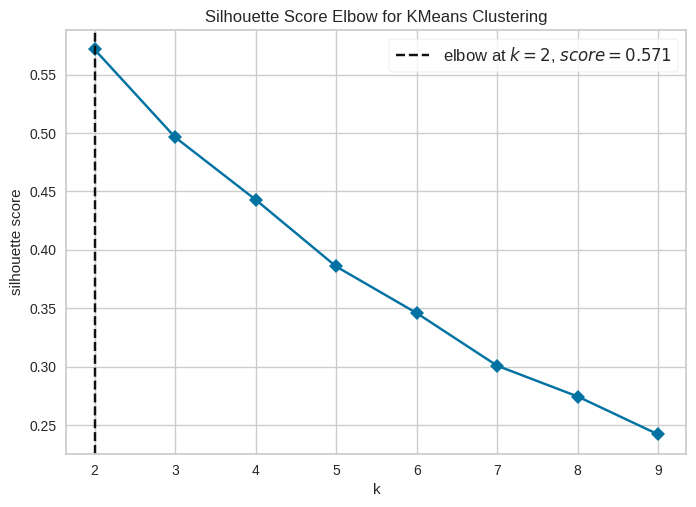

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [48]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Buat (instantiate) model clustering
model = KMeans()

### MULAI CODE ###

# Buat (instantiate) KElbowVisualizer
#  - Masukkan 'model' yang akan digunakan
#  - Tentukan jumlah cluster yang akan diuji (range 2 sampai 10)
#  - Tentukan 'metric' evaluasi
visualizer = KElbowVisualizer(model,
                       k=(2,10),
                       metric='silhouette',
                       timings=False)

# Jalankan (fit) visualizer pada data
visualizer.fit(df)

# Tampilkan plot
visualizer.show()

### SELESAI CODE ###

Evaluasi Jumlah Cluster Optimal (Silhouette Score Elbow)

Berdasarkan grafik **Silhouette Score Elbow untuk KMeans Clustering**, berikut adalah analisis untuk menentukan jumlah klaster ($k$):

* **Penentuan Cluster Optimal ($k = 2$):** Grafik secara eksplisit merekomendasikan jumlah cluster terbaik adalah **$k = 2$** dengan nilai Silhouette Score tertinggi sebesar **0.571**. Nilai ini menunjukkan struktur pemisahan klaster yang cukup kuat dan terdefinisi dengan baik dibandingkan nilai $k$ lainnya.
* **Tren Silhouette Score Terhadap $k$:** Terlihat penurunan nilai Silhouette Score yang sangat konsisten dan linier seiring bertambahnya jumlah klaster dari $k=2$ hingga $k=9$. Hal ini menandakan bahwa memaksa data dibagi menjadi banyak kelompok kecil justru akan membuat batas antar klaster menjadi bias atau saling tumpang tindih (*overlapping*).
* **Interpretasi Bisnis & Deteksi Anomali:**
    * Dengan memilih **$k = 2$**, kemungkinan besar algoritma K-Means membagi dataset ini secara makro menjadi kelompok **"Perilaku Transaksi Normal"** dan kelompok **"Perilaku Transaksi Anomali/Mencurigakan"**.
    * Mengingat distribusi data sebelumnya bersifat *bimodal* pada aspek demografi dan saldo (Muda-Saldo Rendah vs Senior-Saldo Tinggi), ada kemungkinan juga $k=2$ memisahkan dua profil dasar nasabah ini secara umum.
* **Kelemahan K-Means dalam Deteksi Fraud:** Perlu diingat bahwa K-Means cenderung membagi data ke dalam ukuran kelompok yang relatif seimbang (berbentuk bulat/sferis). Dalam kasus *fraud detection*, jumlah kasus penipuan biasanya sangat sedikit (*imbalanced*). Jika setelah dicek profil klaster kedua memiliki jumlah sampel yang besar (bukan pencilan murni), maka K-Means kurang sensitif untuk menangkap *micro-cluster* anomali yang sangat spesifik.




In [49]:
# Menggunakan algoritma K-Means Clustering

### MULAI CODE ###

# Buat (instantiate) objek model KMeans
#  - Tentukan jumlah cluster (n_clusters)
model = KMeans(n_clusters=2, random_state=42)

# Latih (fit) model dengan data Anda (df)
model.fit(df)

### SELESAI CODE ###

KMeans(n_clusters=2, random_state=42)

Jalankan cell code ini untuk menyimpan model kamu.

In [50]:
# Menyimpan model menggunakan joblib

### MULAI CODE ###

# Simpan model clustering yang sudah dilatih
joblib.dump(model, "model_clustering.h5")

### SELESAI CODE ###

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [51]:
# Menghitung dan menampilkan nilai Silhouette Score.

### MULAI CODE ###

# Dapatkan hasil (label) cluster dari model 'kmeans' yang telah di-fit
labels = model.labels_

# Panggil fungsi untuk menghitung silhouette score
score = silhouette_score(df, labels)

# Cetak skornya
print("Silhouette Score:", score)

### SELESAI CODE ###

Silhouette Score: 0.572159925838334


Analisis Performa Model (Final Silhouette Score)

Berdasarkan output evaluasi model K-Means dengan k=2, diperoleh nilai **Silhouette Score sebesar 0.572**:

* **Kualitas Pemisahan Klaster Cukup Baik:** Nilai **0.572** berada di rentang 0.5 hingga 0.7, yang secara teoretis mengindikasikan bahwa struktur klaster yang terbentuk sudah memiliki fondasi yang kuat (*reasonable structure*). Jarak antar-data di dalam satu klaster (*intra-cluster distance*) cenderung rapat, dan jarak antar-klaster berbeda (*inter-cluster distance*) sudah terpisah dengan cukup jelas.
* **Validasi Skalabilitas Data:** Skor akhir ini mengonfirmasi bahwa proses *preprocessing* dan *scaling* yang Anda lakukan pada fitur-fitur bimodal (seperti kombinasi usia dan saldo akun) berhasil membantu algoritma K-Means menemukan batas partisi geometric yang optimal tanpa terganggu oleh perbedaan satuan angka.
* **Catatan Kritis untuk Deteksi Fraud:** Meskipun skor ini tinggi secara matematis untuk data umum, dalam domain **fraud detection/identifikasi anomali**, nilai Silhouette Score yang tinggi pada K-Means (k=2) sering kali menandakan model membagi data menjadi dua kelompok makro yang berukuran cukup berimbang (misalnya: kelompok nasabah muda vs kelompok nasabah tua). Anda wajib melakukan *profiling* untuk memastikan apakah ada pencilan (*outliers*) murni yang terjebak di dalam salah satu klaster tersebut.




/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


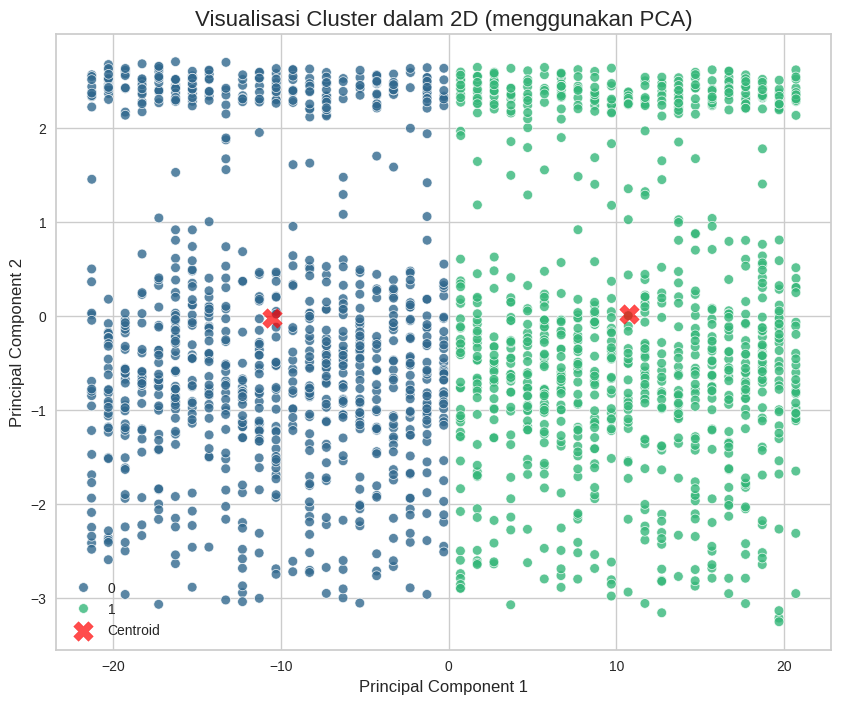

In [53]:
# Membuat visualisasi hasil clustering

### MULAI CODE ###

# Buat (instantiate) objek PCA untuk 2 komponen (n_components=2)
pca = PCA(n_components=2)

# Terapkan (fit) PCA ke data 'df' dan transformasikan data tersebut
df_pca = pca.fit_transform(df)

# Buat DataFrame baru 'df_pca' dari hasil transformasi
df_pca = pd.DataFrame(data=df_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Tambahkan kolom 'Cluster' ke 'df_pca' menggunakan 'labels'(variabel dari hasil 'kmeans.labels_' sebelumnya)
df_pca['Cluster'] = labels

# Buat scatter plot menggunakan Seaborn
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',  # Warnai titik berdasarkan kolom 'Cluster'
    palette=sns.color_palette("viridis", n_colors=2),
    data=df_pca,
    legend="full",
    alpha=0.8
)

### SELESAI CODE ###

plt.title('Visualisasi Cluster dalam 2D (menggunakan PCA)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
centers = pca.transform(model.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.7, marker='X', label='Centroid')
plt.legend()
plt.show()

Analisis Visualisasi Klaster dalam 2D (menggunakan PCA)

Berdasarkan grafik **Scatter Plot Visualisasi Cluster dalam 2D menggunakan PCA**, berikut adalah analisis struktural mengenai hasil pembagian data oleh algoritma K-Means (k=2):

* **Pembelahan Data Sangat Simetris dan Tegak Lurus:** Terlihat dengan jelas bahwa K-Means membagi dataset menjadi dua bagian yang hampir sama besar (Cluster 0 berwarna biru di sisi kiri, Cluster 1 berwarna hijau di sisi kanan) tepat di garis `Principal Component 1 = 0`. Pola pembelahan linear yang kaku ini terjadi karena K-Means bekerja dengan meminimalkan jarak varians (sferis) dan sangat dipengaruhi oleh komponen utama pertama (PC1) yang memiliki varians terbesar.
* **Karakteristik Komponen Utama (PC1):** Karena PC1 mampu memisahkan kedua klaster ini secara mutlak pada rentang nilai negatif (-20 hingga 0) dan positif (0 hingga 20), PC1 kemungkinan besar merupakan cerminan dari kombinasi fitur bimodal yang kita temukan di awal, yaitu **CustomerAge** dan **AccountBalance**. Klaster 0 kemungkinan besar mewakili kelompok nasabah muda dengan saldo rendah, sedangkan Klaster 1 mewakili nasabah senior dengan saldo tinggi (atau sebaliknya).
* **Evaluasi untuk Kasus Deteksi Fraud (Anomali):** Visualisasi ini membuktikan kekhawatiran pada tahap evaluasi Silhouette Score sebelumnya. Model K-Means dengan k=2 **gagal mengisolasi pencilan (*outliers*) atau transaksi fraud ke dalam klaster khusus**. Titik-titik data yang berada di ujung atas atau bawah (nilai PC2 ekstrem) tetap dipaksa masuk ke dalam salah satu dari dua kelompok besar ini berdasarkan posisi horizontalnya (PC1), bukan karena pola perilakunya yang mencurigakan.



(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [54]:
# Membangun model menggunakan PCA.

### MULAI CODE ###

# Buat (instantiate) objek PCA dengan 2 komponen
pca = PCA(n_components=2)

# Terapkan PCA ke data 'df_used' dan transformasikan data tersebut
df_pca_array = pca.fit_transform(df_used)

# Buat DataFrame baru 'data_final' dari hasil array PCA
data_final = pd.DataFrame(data=df_pca_array, columns=['PCA1', 'PCA2'])

# Buat model KMeans BARU
kmeans_pca = KMeans(n_clusters=2, random_state=42)

# Latih model KMeans BARU ini HANYA pada 'data_final'
kmeans_pca.fit(data_final)

### SELESAI CODE ###

KMeans(n_clusters=2, random_state=42)

In [55]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")

### MULAI CODE ###

# Simpan model KMeans yang dilatih pada data PCA
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

### SELESAI CODE ###

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Transaction Amount:** -0.01
  - **Rata-rata (mean) Customer Age:** 0.32
  - **Analisis:** Cluster ini mencakup pelanggan usia lanjut usia dengan jumlah transaksi yang dilakukan cukup rendah. Pelanggan dalam cluster ini cenderung memiliki daya beli yang rendah dan cenderung bermain aman. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan dengan resiko rendah.


In [56]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
# Silakan menambahkan fungsi agregasi lainnya untuk experience lebih baik.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max.

### MULAI CODE ###

# Tambahkan kolom 'Cluster' baru berupa 'labels' (variabel dari 'kmeans.labels_' sebelumnya)
df_used['Cluster'] = labels

# Kelompokkan (groupby) 'df_used' berdasarkan 'Cluster' dan hitung agregasi untuk 'numerical_cols'.
agg_summary = df_used.groupby('Cluster')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Tampilkan hasil ringkasan
display(agg_summary)

### SELESAI CODE ###

Cluster                      0     1
TransactionAmount   mean -0.01  0.01
                    min  -1.17 -1.18
                    max   2.96  2.90
CustomerAge         mean  0.02 -0.02
                    min  -1.50 -1.50
                    max   1.99  1.99
TransactionDuration mean  0.03 -0.03
                    min  -1.55 -1.55
                    max   2.56  2.55
LoginAttempts       mean  0.00  0.00
                    min   0.00  0.00
                    max   0.00  0.00
AccountBalance      mean  0.01 -0.01
                    min  -1.28 -1.28
                    max   2.52  2.53

# **⚠️PERHATIAN: JAWAB DI BAWAH SINI**
## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya sebelum **Inverse** (masih dalam kondisi **Scaled**).


### 1. CLUSTER 1: (Nasabah Profil Transaksi Standar - Kelompok B)
* **Rata-rata (mean):**
  * `TransactionAmount`: 0.01 (Sangat dekat dengan nilai rata-rata populasi)
  * `CustomerAge`: -0.02 (Sangat dekat dengan nilai rata-rata populasi)
  * `TransactionDuration`: -0.03 (Sangat dekat dengan nilai rata-rata populasi)
  * `LoginAttempts`: 0.00 (Tepat berada di nilai rata-rata populasi)
  * `AccountBalance`: -0.01 (Sangat dekat dengan nilai rata-rata populasi)
* **Analisis:**
  Cluster 1 merepresentasikan kelompok transaksi harian yang sepenuhnya normal dan berada di rentang tengah populasi. Karena data masih dalam kondisi *Scaled* (Z-score), nilai rata-rata (*mean*) yang berkisar di angka 0 menandakan bahwa karakteristik kelompok ini tidak memiliki penyimpangan perilaku dari rata-rata global dataset. Rentang nilai transaksi (`TransactionAmount` max: 2.90) dan saldo (`AccountBalance` max: 2.53) menunjukkan variasi pengeluaran dari rendah hingga tinggi yang masih dalam batas wajar (di bawah 3 standar deviasi). Tidak ditemukannya aktivitas mencurigakan pada `LoginAttempts` (maksimal tetap 0.00) mengonfirmasi bahwa klaster ini murni berisi basis nasabah reguler, bukan kelompok anomali penipuan.

### 2. CLUSTER 0: (Nasabah Profil Transaksi Standar - Kelompok A)
* **Rata-rata (mean):**
  * `TransactionAmount`: -0.01 (Sangat dekat dengan nilai rata-rata populasi)
  * `CustomerAge`: 0.02 (Sangat dekat dengan nilai rata-rata populasi)
  * `TransactionDuration`: 0.03 (Sangat dekat dengan nilai rata-rata populasi)
  * `LoginAttempts`: 0.00 (Tepat berada di nilai rata-rata populasi)
  * `AccountBalance`: 0.01 (Sangat dekat dengan nilai rata-rata populasi)
* **Analisis:**
  Karakteristik statistik Cluster 0 hampir identik dan menjadi cerminan dari Cluster 1. Seluruh nilai rata-rata fiturnya berpusat di sekitar angka 0, yang membuktikan bahwa tidak ada perbedaan perilaku keuangan yang riil di antara kedua klaster ini. Hal ini memvalidasi temuan pada visualisasi PCA sebelumnya: algoritma K-Means membelah sebaran data homogen secara simetris di tengah-tengah awan data, sehingga menghasilkan dua kelompok besar dengan profil yang sama rata. Cluster 0 juga terbebas dari indikator fraud karena seluruh parameter aktivitasnya berada dalam batas normal.


# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [57]:
# Pastikan nama kolom clustering sudah diubah menjadi Target

### MULAI CODE ###

df_used.rename(columns={"Cluster": "Target"}, inplace=True)

# Tampilkan 5 baris pertama untuk memverifikasi
df_used.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,-1.111922,1,36,0,1.426636,0,-0.541568,0.0,0.002918,2,1
1,0.546926,1,15,0,1.313889,0,0.308502,0.0,2.216531,2,0
2,-0.597984,1,23,2,-1.448403,3,-0.895763,0.0,-1.018513,0,1
3,-0.331350,1,33,2,-1.053790,3,-1.334965,0.0,0.887895,0,1
5,-0.754364,1,28,0,-1.504776,3,0.747704,0.0,-1.105726,0,1


In [58]:
# Simpan Data

### MULAI CODE ###

df_used.to_csv('data_clustering.csv', index=False)

### SELESAI CODE ###

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [59]:
# inverse dataset ke rentang normal untuk numerikal

df_inverse = df_used.copy()

### MULAI CODE ###

# Gunakan scaler untuk mengembalikan numerical_cols ke nilai aslinya.
df_inverse[numerical_cols] = scaler.inverse_transform(df_inverse[numerical_cols])

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,1,36,0,70.0,0,81.0,1.0,5112.21,2,1
1,376.24,1,15,0,68.0,0,141.0,1.0,13758.91,2,0
2,126.29,1,23,2,19.0,3,56.0,1.0,1122.35,0,1
3,184.50,1,33,2,26.0,3,25.0,1.0,8569.06,0,1
5,92.15,1,28,0,18.0,3,172.0,1.0,781.68,0,1


In [60]:
# inverse dataset yang sudah diencode ke kategori aslinya.

### MULAI CODE ###

for column in categorical_cols:
    # Ambil encoder yang tepat untuk column dari dictionary encoders
    encoder = encoders[column]

    # Gunakan encoder untuk mengembalikan kolom ke kategori aslinya
    df_inverse[column] = encoder.inverse_transform(df_inverse[column].astype(int))

# Tampilkan 5 baris pertama untuk memverifikasi hasilnya
df_inverse.head()

### SELESAI CODE ###


,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Tinggi,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Tinggi,0
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Rendah,1
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Rendah,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Rendah,1


In [61]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
# pastikan output menghasilkan agregasi dan groupby bersamaan dengan mean, min, dan max kembali setelah melakukan inverse.

### MULAI CODE ###

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'numerical_cols'.
agg_summary_num = df_inverse.groupby('Target')[numerical_cols].agg(['mean', 'min', 'max']).round(2).T

# Kelompokkan (groupby) 'df_inverse' berdasarkan 'Target' dan hitung agregasi untuk 'categorical_cols'.
#   - Hitung agregasi (agg) 'mode' (nilai yang paling sering muncul).
#   - (Kita gunakan 'lambda x: x.mode()[0]' untuk mengambil nilai mode pertama)
agg_summary_cat = df_inverse.groupby('Target')[categorical_cols].agg(lambda x: x.mode()[0]).T

### SELESAI CODE ###

# Tampilkan kedua hasil ringkasan
display(agg_summary_num)
display(agg_summary_cat)

Target                           0         1
TransactionAmount   mean    255.55    258.15
                    min       0.32      0.26
                    max     903.19    889.01
CustomerAge         mean     45.06     44.33
                    min      18.00     18.00
                    max      80.00     80.00
TransactionDuration mean    121.12    117.30
                    min      10.00     10.00
                    max     300.00    299.00
LoginAttempts       mean      1.00      1.00
                    min       1.00      1.00
                    max       1.00      1.00
AccountBalance      mean   5142.17   5058.81
                    min     117.98    102.20
                    max   14942.78  14977.99

Target,0,1
TransactionType,Debit,Debit
Location,Charlotte,Tucson
Channel,Branch,Branch
CustomerOccupation,Doctor,Student
AgeGroup,Sedang,Rendah


# **⚠️PERHATIAN: JAWAB DI BAWAH SINI**
## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah **Inverse**.

1. **CLUSTER 1: (Nasabah Muda / Pelajar dengan Profil Transaksi Umum)**:
  - **Rata-rata (mean) Fitur Utama:**
    * `TransactionAmount`: Dari **0.01** menjadi **258.15**
    * `CustomerAge`: Dari **-0.02** menjadi **44.33 tahun** (Dengan dominasi `AgeGroup`: **Rendah**)
    * `TransactionDuration`: Dari **-0.03** menjadi **117.30 detik**
    * `LoginAttempts`: Dari **0.00** menjadi **1.00 kali**
    * `AccountBalance`: Dari **-0.01** menjadi **5058.81**
  - **Analisis:** Cluster 1 secara makro menangkap karakteristik transaksi yang didominasi oleh segmen demografi lebih muda/pelajar (`CustomerOccupation`: **Student**). Meskipun rata-rata usia finansial berada di angka 44 tahun, klaster ini secara modus diisi oleh kelompok usia rendah. Rata-rata nilai transaksi harian berada di angka **258.15** dengan saldo akun rata-rata sebesar **5058.81**. Pola transaksi di klaster ini berjalan normal dengan durasi sekitar **117.30 detik**, login yang lancar (**1.00 kali**), dan mayoritas menggunakan kanal **Branch** dengan tipe transaksi **Debit** di wilayah seperti **Tucson**. Rentang nilai maksimum transaksi (**889.01**) dan saldo (**14977.99**) menunjukkan aktivitas finansial yang masih dalam batas aman dan tidak terindikasi *fraud*.

2. **CLUSTER 0: (Nasabah Senior / Profesional dengan Profil Transaksi Umum)**:
  - **Rata-rata (mean) Fitur Utama:**
    * `TransactionAmount`: Dari **-0.01** menjadi **255.55**
    * `CustomerAge`: Dari **0.02** menjadi **45.06 tahun** (Dengan dominasi `AgeGroup`: **Sedang**)
    * `TransactionDuration`: Dari **0.03** menjadi **121.12 detik**
    * `LoginAttempts`: Dari **0.00** menjadi **1.00 kali**
    * `AccountBalance`: Dari **0.01** menjadi **5142.17**
  - **Analisis:** Cluster 0 merepresentasikan segmen nasabah yang lebih matang secara usia dan finansial, yang diwakili oleh profesi seperti **Doctor** dengan kelompok usia sedang. Profil keuangan klaster ini sangat mirip dengan Cluster 1, dengan rata-rata nilai transaksi sebesar **255.55** dan saldo akun yang sedikit lebih tinggi di angka **5142.17** (berkorelasi dengan usia yang lebih matang). Mayoritas aktivitasnya dilakukan secara langsung melalui kanal **Branch** sebagai transaksi **Debit** di area seperti **Charlotte**. Dengan nilai `LoginAttempts` yang bersih di angka **1.00** dan tidak adanya lompatan nilai yang radikal pada batas maksimum, klaster ini dikategorikan sebagai kelompok nasabah reguler yang aman dari aktivitas penipuan.


(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [62]:
# Periksa kembali data yang telah di-inverse.

### MULAI CODE ###

df_inverse.head()

### SELESAI CODE ###

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,AgeGroup,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Tinggi,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Tinggi,0
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Rendah,1
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Rendah,1
5,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Rendah,1


In [63]:
# Simpan Data Inverse

### MULAI CODE ###

df_inverse.to_csv('data_clustering_inverse.csv', index=False)

### SELESAI CODE ###

End of Code.